In [1]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [2]:
# train/test data separation
import pandas as pd
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv('../data/raw/emotions.csv')

In [4]:
# x:feature, y:answer
x = df.drop(columns=['label'])
y = df['label']

In [5]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, 
    test_size=0.2, # 20% for tests, 80% for training
    random_state=42, 
    stratify=y 
)
print("Training set", x_train.shape) 
print("Testing set", x_test.shape) 
print()
print("Training label distribution:" )
print(y_train.value_counts()) 

Training set (1705, 2548)
Testing set (427, 2548)

Training label distribution:
label
NEUTRAL     573
NEGATIVE    566
POSITIVE    566
Name: count, dtype: int64


In [6]:
import numpy as np
x_train = np.sign(x_train) * np.log1p(np.abs(x_train))
x_test = np.sign(x_test) * np.log1p(np.abs(x_test))

In [7]:
# scaling
from sklearn.preprocessing import StandardScaler

In [8]:
scaler = StandardScaler() 

In [9]:
x_train_scaled = scaler.fit_transform(x_train)

x_test_scaled = scaler.transform(x_test)

print("x_train mean before scaling: ", x_train.values.mean())
print("x_train mean after scaling: ", x_train_scaled.mean())
print()
print("x_train standard deviation before scaling: ", x_train.values.std())
print("x_train standard deviation after scaling: ", x_train_scaled.std())

x_train mean before scaling:  0.9187286294800904
x_train mean after scaling:  4.033290180751062e-18

x_train standard deviation before scaling:  4.873345630654151
x_train standard deviation after scaling:  0.9999999999999999


In [10]:
# PCA
from sklearn.decomposition import PCA

In [11]:
pca = PCA(n_components=0.95, random_state=42)

x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

print("original feature number: ", x_train_scaled.shape[1]) 
print("feature number after PCA: ", x_train_pca.shape[1])
print()
print("ratio of information after PCA: ", pca.explained_variance_ratio_.sum())

original feature number:  2548
feature number after PCA:  538

ratio of information after PCA:  0.950087504290795


In [12]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score 

In [13]:
log_reg = LogisticRegression(max_iter=1000, random_state=42) 
log_reg.fit(x_train_pca, y_train)
y_pred = log_reg.predict(x_test_pca)
accuracy = accuracy_score(y_test, y_pred)
print("Logisitc Regression accuracy: ", accuracy)

Logisitc Regression accuracy:  0.9601873536299765


In [14]:
# SVM 
from sklearn.svm import SVC # SVC(Support Vector Classification)

In [15]:
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(x_train_pca, y_train)
y_pred_svm = svm_model.predict(x_test_pca)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("SVM accuracy: ", accuracy_svm)

SVM accuracy:  0.9391100702576113


In [16]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, f1_score
import matplotlib.pyplot as plt
import joblib

In [17]:
# Pipeline (Scaler -> PCA -> model)
log_reg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('clf', SVC(kernel='rbf', random_state=42))
])

In [18]:
# 5-Fold test
x_log = np.sign(x) * np.log1p(np.abs(x))
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1_macro']
log_reg_cv = cross_validate(log_reg_pipe, x_log, y, cv=skf, scoring=scoring)
svm_cv = cross_validate(svm_pipe, x_log, y, cv=skf, scoring=scoring)

print("[Logistic Regression] 5-Fold result")
print(" accuracy: mean %.4f (standard deviation %.4f)" % (log_reg_cv['test_accuracy'].mean(), log_reg_cv['test_accuracy'].std()))
print(" f1_macro: mean %.4f (standard deviation %.4f)" % (log_reg_cv['test_f1_macro'].mean(), log_reg_cv['test_f1_macro'].std()))
print()
print("[SVM] 5-Fold result")
print(" accuracy: mean %.4f (standard deviation %.4f)" % (svm_cv['test_accuracy'].mean(), svm_cv['test_accuracy'].std()))
print(" f1_macro: mean %.4f (standard deviation %.4f)" % (svm_cv['test_f1_macro'].mean(), svm_cv['test_f1_macro'].std()))

[Logistic Regression] 5-Fold result
 accuracy: mean 0.9653 (standard deviation 0.0075)
 f1_macro: mean 0.9652 (standard deviation 0.0076)

[SVM] 5-Fold result
 accuracy: mean 0.9409 (standard deviation 0.0091)
 f1_macro: mean 0.9404 (standard deviation 0.0093)


In [19]:
# classification_report
log_reg_pipe.fit(x_train, y_train) 
y_pred_report = log_reg_pipe.predict(x_test)
print(classification_report(y_test, y_pred_report))

              precision    recall  f1-score   support

    NEGATIVE       0.93      0.96      0.94       142
     NEUTRAL       1.00      1.00      1.00       143
    POSITIVE       0.96      0.92      0.94       142

    accuracy                           0.96       427
   macro avg       0.96      0.96      0.96       427
weighted avg       0.96      0.96      0.96       427



In [20]:
# repeating tests with different conditions
results = []
pca_options = [0.90, 0.95, 0.99]

for n_comp in pca_options: 
    # Logistic Regression
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_comp, random_state=42)),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ])
    cv_res = cross_validate(pipe, x_log, y, cv=skf, scoring=scoring)
    results.append({
        'model': 'LogisticRegression',
        'condition': f'PCA={n_comp}',
        'accuracy_mean': cv_res['test_accuracy'].mean(),
        'accuracy_std': cv_res['test_accuracy'].std(),
        'f1_mean': cv_res['test_f1_macro'].mean(),
        'f1_std': cv_res['test_f1_macro'].std(),
    })

    #SVM
    for kernel in ['rbf', 'linear']:
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=n_comp, random_state=42)),
            ('clf', SVC(kernel=kernel, random_state=42))
        ])
        cv_res = cross_validate(pipe, x_log, y, cv=skf, scoring=scoring)
        results.append({
            'model': f'SVM({kernel})',
            'condition': f'PCA={n_comp}',
            'accuracy_mean': cv_res['test_accuracy'].mean(),
            'accuracy_std': cv_res['test_accuracy'].std(),
            'f1_mean': cv_res['test_f1_macro'].mean(),
            'f1_std': cv_res['test_f1_macro'].std(),
        })

results_df = pd.DataFrame(results)
results_df

,model,condition,accuracy_mean,accuracy_std,f1_mean,f1_std
0,LogisticRegression,PCA=0.9,0.967167,0.007421,0.967080,0.007457
1,SVM(rbf),PCA=0.9,0.941366,0.009519,0.940890,0.009720
2,SVM(linear),PCA=0.9,0.963884,0.006227,0.963788,0.006321
3,LogisticRegression,PCA=0.95,0.965286,0.007494,0.965183,0.007562
4,SVM(rbf),PCA=0.95,0.940897,0.009095,0.940443,0.009281
5,SVM(linear),PCA=0.95,0.968573,0.006404,0.968458,0.006416
6,LogisticRegression,PCA=0.99,0.968105,0.005265,0.968039,0.005301
7,SVM(rbf),PCA=0.99,0.940428,0.008357,0.940018,0.008479
8,SVM(linear),PCA=0.99,0.973735,0.003741,0.973681,0.003730


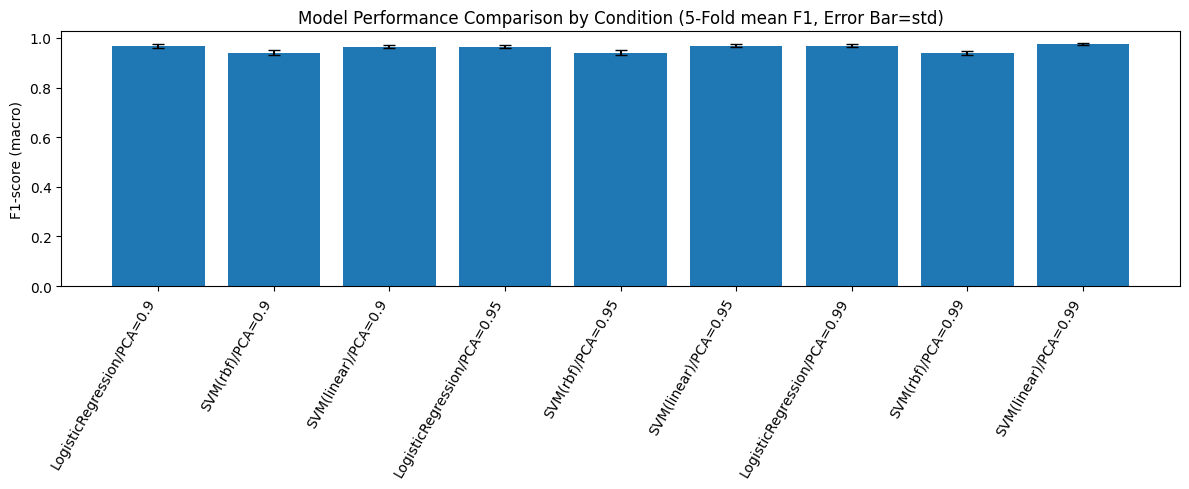

In [21]:
# comparing results with bar graph
labels = results_df['model'] + '/' + results_df['condition']
x_pos = np.arange(len(results_df))

fig, ax = plt.subplots(figsize=(12,5))
ax.bar(x_pos, results_df['f1_mean'], yerr=results_df['f1_std'], capsize=4)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=60, ha='right')
ax.set_ylabel('F1-score (macro)')
ax.set_title('Model Performance Comparison by Condition (5-Fold mean F1, Error Bar=std)')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

In [22]:
best_row = results_df.loc[results_df['f1_mean'].idxmax()]
print('best performance combination:')
print(best_row)

best_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.99, random_state=42)),
    ('clf', SVC(kernel='linear', random_state=42))
])

best_pipe.fit(x_train, y_train)

joblib.dump(best_pipe, 'best_model.pkl')
print("best_model.pkl save completed!")
    

best performance combination:
model            SVM(linear)
condition           PCA=0.99
accuracy_mean       0.973735
accuracy_std        0.003741
f1_mean             0.973681
f1_std               0.00373
Name: 8, dtype: object
best_model.pkl save completed!
